## Playstyle analysis (EPL 2003/04 vs 2015/16)

Compare how Premier League playstyle changed between **2003/04** and **2015/16**.

**Headline questions:**
1. How many **passes per match**?
2. How **long are possessions** (events per possession, passes per possession, duration in seconds)?

Additional themes: pressing, direct play, physicality, chance quality.

**Visuals (section 3):** pass-length & possession-duration histograms, team/player pitch heatmaps, match tempo by minute.

**Note:** 2003/04 has only **38 matches** vs **380** in 2015/16 — use boxplots and treat means as illustrative.

In [47]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR, RAW_DIR
from src.metrics import (
    ERA_A,
    ERA_B,
    EVENT_COLS,
    build_era_comparison,
    build_match_passes,
    build_match_team,
    build_possession_chains,
    build_season_metrics,
    headline_summary,
    passes_season_summary,
    possession_season_summary,
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

matches_df = pd.read_csv(RAW_DIR / "matches.csv")
events_path = RAW_DIR / "events.csv"
events_df = pd.read_csv(events_path, usecols=EVENT_COLS, low_memory=False)

In [55]:
match_meta = matches_df[["match_id", "season", "match_date"]].drop_duplicates()
analysis_events = events_df.merge(match_meta, on="match_id", how="inner")

matches_by_season = match_meta.groupby("season").agg(matches=("match_id", "nunique"))
events_by_season = analysis_events.groupby("season").size().rename("events")

coverage = matches_by_season.join(events_by_season, how="left").fillna(0)
coverage["events"] = coverage["events"].astype(int)

print(f"Total matches in catalog: {match_meta['match_id'].nunique()}")
print(f"Total events captured: {len(analysis_events):,}\n")
print("Matches vs events captured by season:")
print(coverage)

if "2015/2016" in coverage.index:
    est_1516 = coverage.loc["2015/2016", "matches"] * 3404
    actual_1516 = coverage.loc["2015/2016", "events"]
    print(f"\n2015/16 expected ~{est_1516:,.0f} events | actual {actual_1516:,}")
if "2003/2004" in coverage.index:
    est_0304 = coverage.loc["2003/2004", "matches"] * 3404
    actual_0304 = coverage.loc["2003/2004", "events"]
    print(f"2003/04 expected ~{est_0304:,.0f} events | actual {actual_0304:,}")


Total matches in catalog: 418
Total events captured: 1,442,679

Matches vs events captured by season:
           matches   events
season                     
2003/2004       38   129401
2015/2016      380  1313278

2015/16 expected ~1,293,520 events | actual 1,313,278
2003/04 expected ~129,352 events | actual 129,401


In [58]:
match_team = build_match_team(analysis_events)
season_metrics = build_season_metrics(match_team)
season_metrics

print(season_metrics.columns.tolist())

['match_id', 'events', 'passes', 'pass_completion', 'avg_pass_length', 'long_pass_pct', 'crosses', 'through_balls', 'pressure_on_pass_pct', 'counterpresses', 'dribbles', 'duels', 'fouls', 'offensive_recoveries', 'shots', 'xg', 'regular_play_pct', 'passes_into_final_third', 'possession_count', 'avg_possession_chain', 'median_possession_events', 'avg_possession_duration', 'passes_per_possession']


# Posession analysis

We want to see whether there is a different in the system that was being played during the early 2000s and the mid 2000s, whether or not it adheres to the overall consensus that it shifted from a physical, expressive and reactive system to a more structured, systematic and tactical football.

Some questions to consider:
1. Did posession become more structured over time?
2. Did positional discipline increase?
3. Did teams become more tactically predictable?

## 1. Passes per match

Total passes in each game (both teams) and average passes per team.

Passes per match by season:
           matches  mean_total_passes_per_match  \
season                                            
2003/2004       38                        951.7   
2015/2016      380                        970.0   

           median_total_passes_per_match  mean_team_passes_per_match  \
season                                                                 
2003/2004                          954.0                       475.9   
2015/2016                          974.5                       485.0   

           median_team_passes_per_match  
season                                   
2003/2004                         477.0  
2015/2016                         487.2  


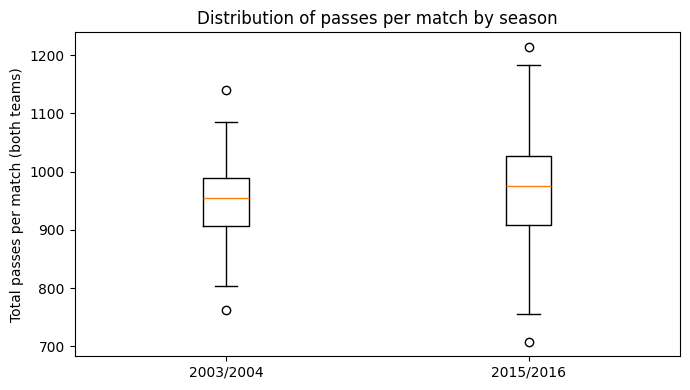

In [50]:
match_passes = build_match_passes(match_team)
passes_summary = passes_season_summary(match_passes)

print("Passes per match by season:")
print(passes_summary)
match_passes.to_csv(PROCESSED_DIR / "epl_passes_per_match.csv", index=False)
passes_summary.to_csv(PROCESSED_DIR / "epl_passes_per_match_summary.csv")

fig, ax = plt.subplots(figsize=(7, 4))
seasons = [ERA_A, ERA_B]
data = [match_passes.loc[match_passes["season"] == s, "total_passes"] for s in seasons if s in match_passes["season"].values]
labels = [s for s in seasons if s in match_passes["season"].values]
ax.boxplot(data, tick_labels=labels)
ax.set_ylabel("Total passes per match (both teams)")
ax.set_title("Distribution of passes per match by season")
plt.tight_layout()
plt.show()

## 2. Possession length

Each StatsBomb `possession` id is one chain. We measure events per chain, passes per chain, and summed `duration` (seconds).

Possession length by season:
           mean_events_per_possession  median_events_per_possession  \
season                                                                
2003/2004                      15.775                          12.0   
2015/2016                      18.247                          13.0   

           mean_passes_per_possession  median_passes_per_possession  \
season                                                                
2003/2004                       4.409                           3.0   
2015/2016                       5.122                           3.0   

           mean_duration_sec  median_duration_sec  
season                                             
2003/2004             14.705               10.378  
2015/2016             16.812               11.309  


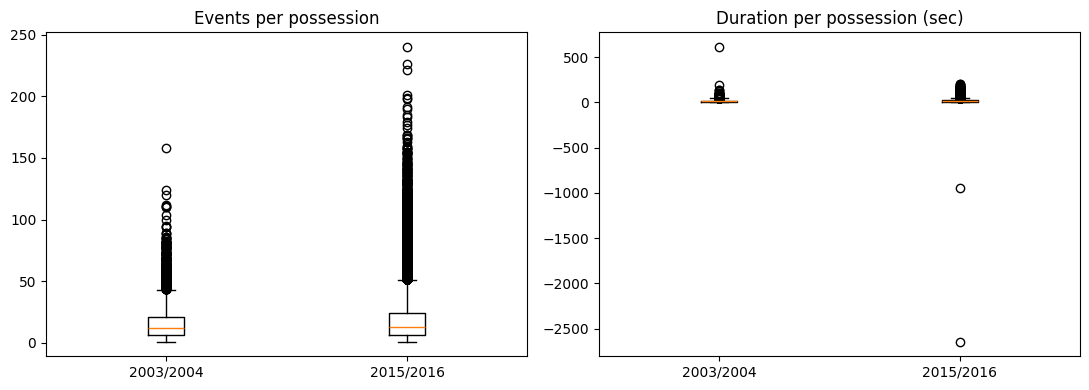

In [51]:
possession_chains = build_possession_chains(analysis_events)
possession_summary = possession_season_summary(possession_chains)

print("Possession length by season:")
print(possession_summary)
possession_summary.to_csv(PROCESSED_DIR / "epl_possession_length.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["event_count", "duration_sec"],
    ["Events per possession", "Duration per possession (sec)"],
):
    data = [
        possession_chains.loc[possession_chains["season"] == s, col]
        for s in [ERA_A, ERA_B]
        if s in possession_chains["season"].values
    ]
    ax.boxplot(data, tick_labels=[ERA_A, ERA_B])
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [52]:
comparison = build_era_comparison(season_metrics)
comparison

2003/2004  2015/2016  \
theme                          metric                                           
Passes & possession (headline) passes                      475.868    485.025   
                               avg_possession_chain          8.674      9.991   
                               median_possession_events      5.184      5.616   
                               avg_possession_duration       8.093      9.213   
                               passes_per_possession         2.425      2.808   
Structure & possession         avg_pass_length              23.193     22.288   
                               long_pass_pct                 0.240      0.224   
                               pass_completion               0.000      0.000   
                               regular_play_pct              0.437      0.446   
                               passes_into_final_third     154.316    166.813   
Pressing & organization        pressure_on_pass_pct          0.144      0.156   
                               counterpresses               55.276     55.662   
                               offensive_recoveries          0.132      0.184   
Direct / individual play       dribbles                     20.553     18.022   
                               crosses                      11.026     12.559   
                               through_balls                 2.289      2.133   
Physical confrontations        duels                        44.013     42.407   
                               fouls                        17.013     12.472   
Chance creation                shots                        12.224     13.001   
                               xg                            1.207      1.275   

                                                         pct_change  
theme                          metric                                
Passes & possession (headline) passes                           1.9  
                               avg_possession_chain            15.2  
                               median_possession_events         8.3  
                               avg_possession_duration         13.8  
                               passes_per_possession           15.8  
Structure & possession         avg_pass_length                 -3.9  
                               long_pass_pct                   -6.7  
                               pass_completion                  NaN  
                               regular_play_pct                 2.1  
                               passes_into_final_third          8.1  
Pressing & organization        pressure_on_pass_pct             8.3  
                               counterpresses                   0.7  
                               offensive_recoveries            39.4  
Direct / individual play       dribbles                       -12.3  
                               crosses                         13.9  
                               through_balls                   -6.8  
Physical confrontations        duels                           -3.6  
                               fouls                          -26.7  
Chance creation                shots                            6.4  
                               xg                               5.6

### Headline answers (team-match / possession-chain averages)

- **Passes per match (both teams):** 2003/2004 averaged **952** total passes per game; 2015/2016 averaged **970** (+1.9%).
- **Possession length (events per possession):** 2003/2004 **15.78** vs 2015/2016 **18.25** (+15.7%).
- **Possession duration (seconds, summed event durations):** 2003/2004 **14.71s** vs 2015/2016 **16.81s** (+14.3%).

*2003/04 sample: 38 matches; 2015/16: 380. Prefer distribution plots over means alone.*


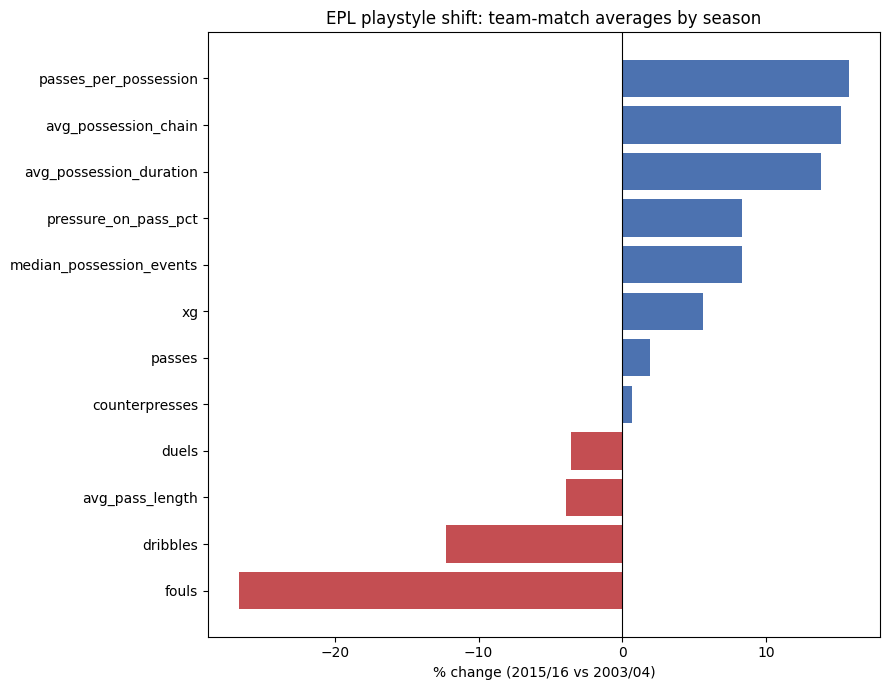

In [53]:
season_metrics.to_csv(PROCESSED_DIR / "epl_season_playstyle_metrics.csv")
comparison.to_csv(PROCESSED_DIR / "epl_playstyle_era_comparison.csv")

print(headline_summary(passes_summary, possession_summary))

headline_metrics = [
    "passes",
    "avg_possession_chain",
    "median_possession_events",
    "avg_possession_duration",
    "passes_per_possession",
    "avg_pass_length",
    "pass_completion",
    "pressure_on_pass_pct",
    "counterpresses",
    "dribbles",
    "duels",
    "fouls",
    "xg",
]

plot_df = comparison.loc[comparison.index.get_level_values("metric").isin(headline_metrics)].copy()
plot_df = plot_df.reset_index(level=0, drop=True)
plot_df = plot_df.sort_values("pct_change")

colors = ["#c44e52" if v < 0 else "#4c72b0" for v in plot_df["pct_change"]]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_df.index, plot_df["pct_change"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("% change (2015/16 vs 2003/04)")
ax.set_title("EPL playstyle shift: team-match averages by season")
plt.tight_layout()
plt.show()

## 3. Distribution & spatial visuals

Histograms (pass length, possession duration), pitch heatmaps (team activity, top players), and match tempo over time.

In [54]:
from src.viz import (
    build_match_tempo,
    ensure_viz_columns,
    plot_match_tempo_timeseries,
    plot_pass_length_histograms,
    plot_player_location_heatmaps,
    plot_possession_duration_histograms,
    plot_team_spatial_heatmap,
)

# Re-merge location/minute/player if cell 1 was run before EVENT_COLS included them
analysis_events = ensure_viz_columns(analysis_events, events_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pass_length_histograms(analysis_events, ax=axes[0])
plot_possession_duration_histograms(possession_chains, ax=axes[1])
plt.tight_layout()
plt.show()

ImportError: cannot import name 'ensure_viz_columns' from 'src.viz' (/home/sothea/Code/soccer_project/src/viz.py)

In [ ]:
from src.viz import ensure_viz_columns

analysis_events = ensure_viz_columns(analysis_events, events_path)
plot_team_spatial_heatmap(analysis_events)
plt.show()

KeyError: 'location'

In [ ]:
from src.viz import ensure_viz_columns

analysis_events = ensure_viz_columns(analysis_events, events_path)

# Top players by touches in each season (min 200 events with location)
for season in [ERA_A, ERA_B]:
    try:
        plot_player_location_heatmaps(analysis_events, season=season, top_n=6)
        plt.show()
    except ValueError as e:
        print(f"{season}: {e}")

KeyError: 'location'

In [ ]:
from src.viz import ensure_viz_columns

analysis_events = ensure_viz_columns(analysis_events, events_path)
match_tempo = build_match_tempo(analysis_events)
match_tempo.to_csv(PROCESSED_DIR / "epl_match_tempo_by_minute.csv", index=False)

plot_match_tempo_timeseries(match_tempo)
plt.show()

KeyError: ['minute']